# Telco Customer Churn Prediction — End-to-End Analysis

**Goal.** Predict which customers of a telecom company are likely to *churn*
(cancel their service) so the business can target them with retention offers
*before* they leave.

**Why it matters.** Acquiring a new customer is far more expensive than keeping
an existing one. Even a small reduction in churn compounds into large revenue
gains, so a model that ranks customers by churn risk is directly actionable.

**Dataset.** The public IBM *Telco Customer Churn* dataset — 7,043 customers, 21
columns describing demographics, the services each customer subscribes to,
their contract/billing setup, and whether they churned.

**Roadmap of this notebook**
1. Load the data and run a data-quality audit
2. Clean the known issues
3. Exploratory data analysis (EDA) — find what drives churn
4. Feature engineering
5. Modelling — compare 3 models with cross-validation, no data leakage
6. Evaluation — the right metrics for an imbalanced problem + threshold tuning
7. Interpretation — which features drive the predictions
8. Business impact & recommendations

## 1. Setup

We import everything up front. scikit-learn provides the modelling stack;
seaborn/matplotlib handle visuals. We fix a `RANDOM_STATE` everywhere so the
entire notebook is **reproducible** — rerun it and you get identical numbers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

## 2. Load the data & audit quality

The first job on any dataset is a **data-quality audit**: shape, types, missing
values, and duplicates. Never trust a file until you've looked.

In [2]:
candidates = [Path("../data/raw/Telco-Customer-Churn.csv"),
              Path("data/raw/Telco-Customer-Churn.csv")]
RAW = next(p for p in candidates if p.exists())

df_raw = pd.read_csv(RAW)
print("Rows, columns:", df_raw.shape)
df_raw.head()

Rows, columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Two things jump out from `.info()`:

* **`TotalCharges` is an `object` (text), not a number.** That's suspicious for
  a money column — usually it means some rows contain a non-numeric value.
* **`SeniorCitizen` is `int64` (0/1)** while every other yes/no column is text.

Let's confirm the `TotalCharges` problem and check for duplicates and class
balance.

In [4]:
# Coercing to numeric turns any non-numeric entry into NaN, exposing bad rows.
tc_numeric = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
bad = tc_numeric.isna()
print("Non-numeric TotalCharges values:", bad.sum())
print("tenure of those rows:", sorted(df_raw.loc[bad, "tenure"].unique()))
print("Duplicate customerIDs:", df_raw["customerID"].duplicated().sum())
print()
print("Target distribution:")
print(df_raw["Churn"].value_counts(normalize=True).round(4))

Non-numeric TotalCharges values: 11
tenure of those rows: [np.int64(0)]
Duplicate customerIDs: 0

Target distribution:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


**Findings & decisions:**

* The 11 blank `TotalCharges` rows **all have `tenure == 0`** — they are
  brand-new customers who haven't completed a billing cycle. Their true total
  spend is `0`, so we'll **impute 0** rather than drop legitimate customers.
* No duplicate IDs — good.
* **~26.5% churn.** This *class imbalance* is important: a model that predicts
  "nobody churns" would be ~73% accurate while being useless. So **accuracy is
  the wrong metric** — we'll lean on ROC-AUC, recall and precision instead.

## 3. Cleaning

Each step below maps to a specific issue we found. Wrapping it in a function
keeps it reproducible and reusable.

In [5]:
def clean(df):
    df = df.copy()
    # 1) TotalCharges -> numeric; the 11 blanks (tenure 0) become 0.
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
    # 2) SeniorCitizen 0/1 -> "No"/"Yes" so all categoricals are uniform text.
    df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
    # 3) Target -> integer 0/1 for modelling.
    df["Churn"] = (df["Churn"] == "Yes").astype(int)
    # 4) customerID is an identifier with no predictive value.
    df = df.drop(columns=["customerID"])
    return df

df = clean(df_raw)
print("Clean shape:", df.shape, "| any nulls?", df.isna().any().any())
df.head()

Clean shape: (7043, 20) | any nulls? False


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 4. Exploratory Data Analysis (EDA)

EDA is where we build intuition for *what drives churn*. Each chart below is a
hypothesis we can later confirm with the model.

### 4.1 How imbalanced is the target?

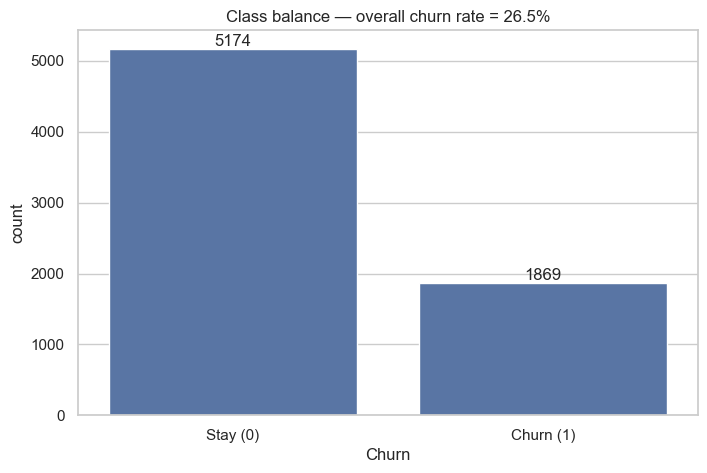

In [6]:
ax = sns.countplot(data=df, x="Churn")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Stay (0)", "Churn (1)"])
ax.set_title(f"Class balance — overall churn rate = {df['Churn'].mean():.1%}")
for c in ax.containers:
    ax.bar_label(c)
plt.show()

### 4.2 Churn rate across key categorical drivers

For each category we plot the **churn rate** (mean of the 0/1 target). The
dashed line is the overall average, so bars above it are higher-risk segments.

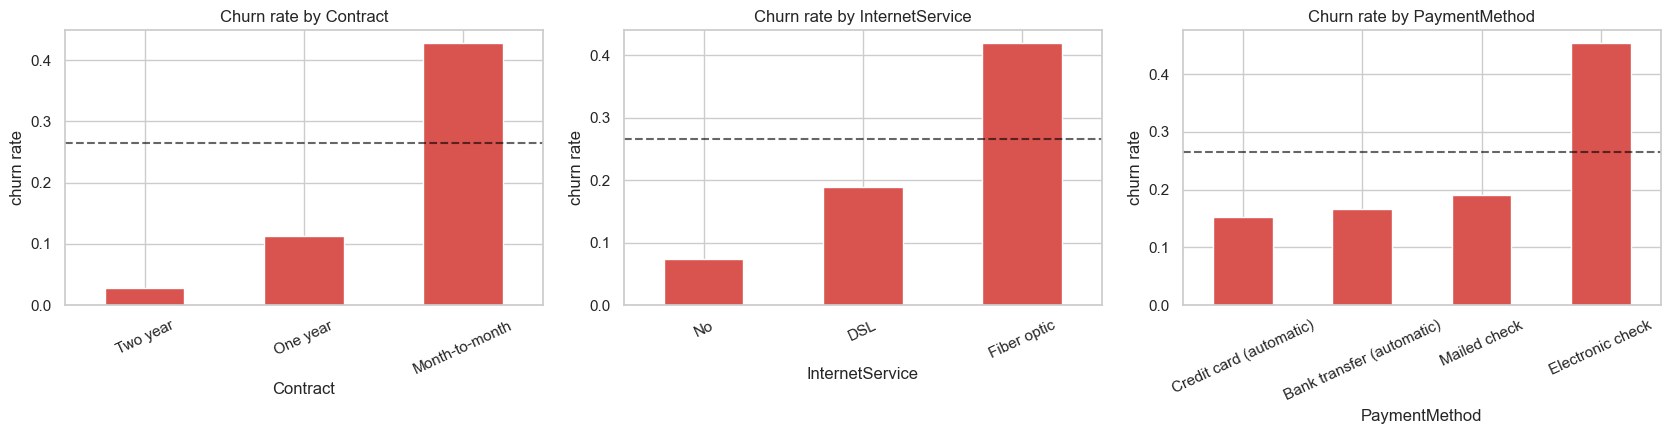

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    (df.groupby(col)["Churn"].mean().sort_values()
       .plot(kind="bar", ax=ax, color="#d9534f"))
    ax.axhline(df["Churn"].mean(), ls="--", color="black", alpha=0.6)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("churn rate")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

Huge signals here:

* **Contract** is the single clearest driver: *month-to-month* customers churn
  dramatically more than those on 1- or 2-year contracts (no lock-in).
* **Fiber-optic** internet customers churn far more than DSL / no-internet —
  likely a price/expectation issue worth flagging to the business.
* **Electronic-check** payers churn more than automatic-payment users.

### 4.3 Numeric features by churn

We compare the distribution of each numeric feature for churners vs. non-churners.

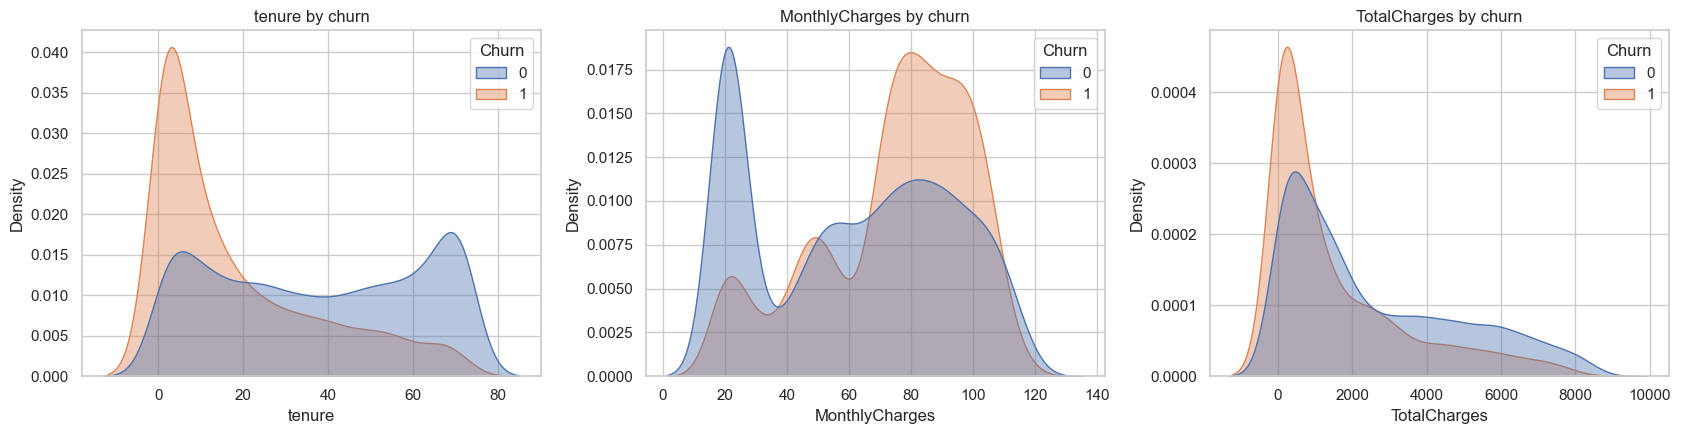

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, common_norm=False,
                alpha=0.4, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout(); plt.show()

* **Tenure**: churn is concentrated among *new* customers — the early months
  are the danger zone. Long-tenured customers rarely leave.
* **MonthlyCharges**: churners skew toward *higher* monthly bills.
* **TotalCharges**: low total spend (a by-product of short tenure) tracks churn.

### 4.4 Correlation among numeric features

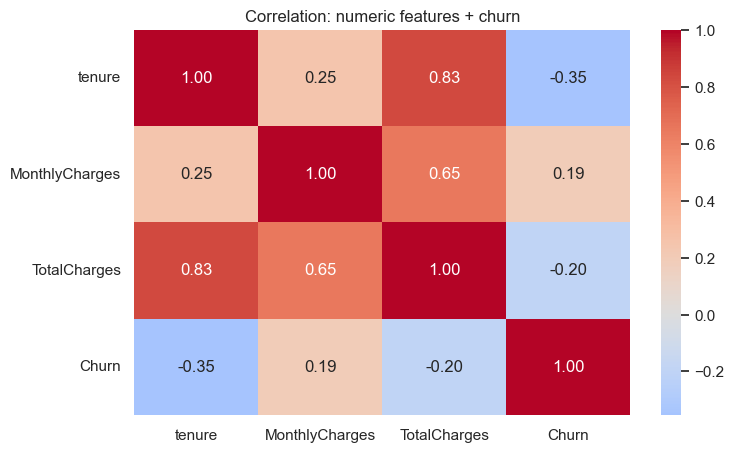

In [9]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation: numeric features + churn")
plt.show()

`tenure` and `TotalCharges` are strongly correlated (the longer you stay, the
more you've paid in total) — a hint of **multicollinearity** we keep in mind
when interpreting linear-model coefficients.

## 5. Feature engineering

We add three features that encode domain intuition the raw columns hide:

* **`num_services`** — how many of the 8 add-on services a customer uses.
  Counting only literal `"Yes"` means `"No internet service"` correctly counts
  as 0. More products → stickier customer.
* **`tenure_group`** — tenure bucketed into bands. Churn is non-linear in
  tenure, so bands help linear models and make the story readable.
* **`avg_charges_per_month`** — lifetime spend ÷ tenure (falling back to
  `MonthlyCharges` for brand-new customers to avoid divide-by-zero).

In [10]:
SERVICE_COLUMNS = ["PhoneService", "MultipleLines", "OnlineSecurity",
                   "OnlineBackup", "DeviceProtection", "TechSupport",
                   "StreamingTV", "StreamingMovies"]

def engineer(df):
    df = df.copy()
    df["num_services"] = (df[SERVICE_COLUMNS] == "Yes").sum(axis=1)
    df["tenure_group"] = pd.cut(
        df["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
        labels=["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5yr+"]).astype(str)
    df["avg_charges_per_month"] = np.where(
        df["tenure"] > 0,
        df["TotalCharges"] / df["tenure"].replace(0, np.nan),
        df["MonthlyCharges"])
    return df

df = engineer(df)
df[["num_services", "tenure_group", "avg_charges_per_month"]].head()

,num_services,tenure_group,avg_charges_per_month
0,1,0-1yr,29.850000
1,3,2-4yr,55.573529
2,3,0-1yr,54.075000
3,3,2-4yr,40.905556
4,1,0-1yr,75.825000


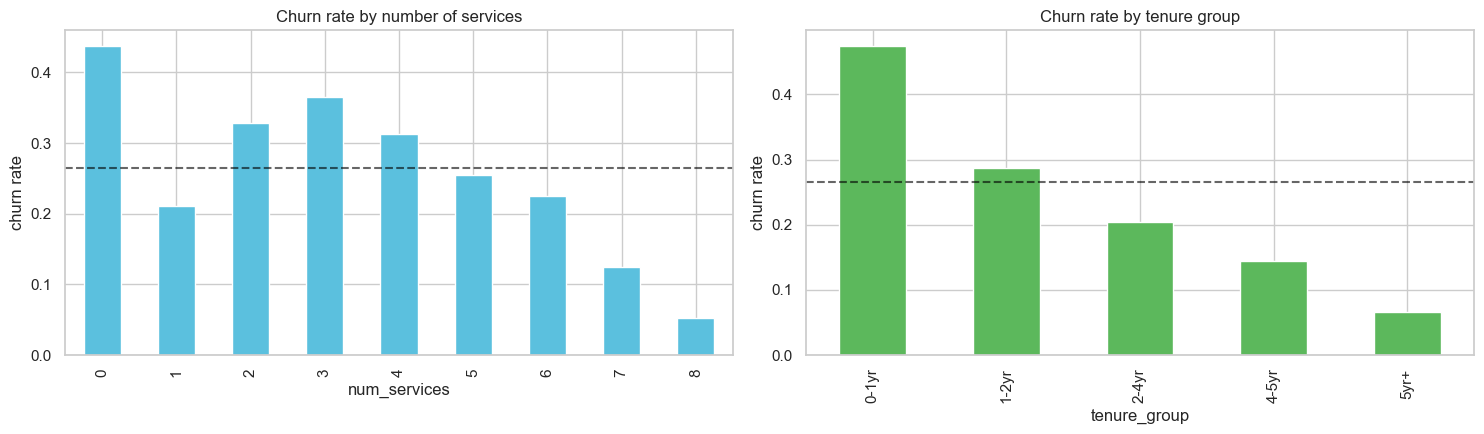

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
df.groupby("num_services")["Churn"].mean().plot(kind="bar", ax=axes[0], color="#5bc0de")
axes[0].axhline(df["Churn"].mean(), ls="--", color="black", alpha=0.6)
axes[0].set_title("Churn rate by number of services"); axes[0].set_ylabel("churn rate")

order = ["0-1yr", "1-2yr", "2-4yr", "4-5yr", "5yr+"]
df.groupby("tenure_group")["Churn"].mean().reindex(order).plot(kind="bar", ax=axes[1], color="#5cb85c")
axes[1].axhline(df["Churn"].mean(), ls="--", color="black", alpha=0.6)
axes[1].set_title("Churn rate by tenure group"); axes[1].set_ylabel("churn rate")
plt.tight_layout(); plt.show()

Both confirm our intuition: more services → lower churn, and churn collapses as
tenure grows.

## 6. Modelling

### 6.1 Train/test split

We hold out 20% of the data as a **test set we never touch during training**.
`stratify=y` keeps the ~26.5% churn rate identical in both splits so the test
set is representative.

In [12]:
y = df["Churn"]
X = df.drop(columns=["Churn"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| test:", X_test.shape)
print("train churn rate:", round(y_train.mean(), 3),
      "| test churn rate:", round(y_test.mean(), 3))

train: (5634, 22) | test: (1409, 22)
train churn rate: 0.265 | test churn rate: 0.265


### 6.2 Preprocessing — and why it lives *inside* a Pipeline

Numeric features need **scaling** (so coefficients are comparable and gradient
solvers converge); categorical features need **one-hot encoding** (turning text
categories into 0/1 columns). A `ColumnTransformer` applies the right transform
to each column group.

The critical part: we put preprocessing **inside an sklearn `Pipeline`** with
the model. During cross-validation this guarantees the scaler/encoder are fit on
the *training folds only* — preventing **data leakage**, the most common way
people accidentally inflate their scores.

In [13]:
numeric_cols = X.select_dtypes("number").columns.tolist()
categorical_cols = X.select_dtypes("object").columns.tolist()

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])
print("numeric:", numeric_cols)
print("categorical:", categorical_cols)

numeric: ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'avg_charges_per_month']
categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


### 6.3 Compare three models with cross-validation

We try three model families that trade interpretability for flexibility:

| Model | Why include it |
|---|---|
| Logistic Regression | Linear, fast, interpretable baseline |
| Random Forest | Bagged trees; captures interactions, robust |
| HistGradientBoosting | sklearn's gradient-boosted trees (XGBoost-style) |

`class_weight="balanced"` up-weights the minority churn class. We score with
**ROC-AUC** (threshold-independent, robust to imbalance) using **5-fold
stratified cross-validation** so each estimate is averaged over 5 train/val
splits — far more reliable than a single split.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=5, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=400, l2_regularization=1.0,
        random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    rows.append({"model": name,
                 "cv_roc_auc": round(scores.mean(), 4),
                 "std": round(scores.std(), 4)})

cv_table = pd.DataFrame(rows).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
cv_table

,model,cv_roc_auc,std
0,Logistic Regression,0.8458,0.0113
1,Random Forest,0.8454,0.0089
2,HistGradientBoosting,0.8301,0.0083


All three land around **0.83–0.85 ROC-AUC**. Logistic Regression is essentially
tied with the tree ensembles here — a great outcome, because it's the **simplest
and most interpretable** model. When a linear model matches the fancy ones, you
ship the linear model.

### 6.4 Fit the best model and evaluate on the untouched test set

In [15]:
best_name = cv_table.iloc[0]["model"]
best_pipe = Pipeline([("prep", preprocess), ("model", models[best_name])])
best_pipe.fit(X_train, y_train)

proba = best_pipe.predict_proba(X_test)[:, 1]
print("Best model:", best_name)
print("Test ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

Best model: Logistic Regression
Test ROC-AUC: 0.8424


### 6.5 Threshold tuning

A classifier outputs a *probability*. The default 0.5 cutoff is rarely optimal
on imbalanced data. We pick the threshold that **maximises F1** on the training
data (never the test set!), trading a little precision for the recall the
business wants — catching would-be churners.

In [16]:
prec, rec, thr = precision_recall_curve(y_train, best_pipe.predict_proba(X_train)[:, 1])
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = thr[int(np.argmax(f1s))]
print("Tuned decision threshold:", round(best_thr, 3))

pred = (proba >= best_thr).astype(int)
print(classification_report(y_test, pred, target_names=["Stay", "Churn"]))

Tuned decision threshold: 0.595
              precision    recall  f1-score   support

        Stay       0.89      0.79      0.84      1035
       Churn       0.55      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



### 6.6 Evaluation plots

* **Confusion matrix** — raw counts of correct/incorrect predictions.
* **ROC curve** — true-positive vs false-positive rate across all thresholds.
* **Precision-Recall curve** — the more informative view under imbalance.

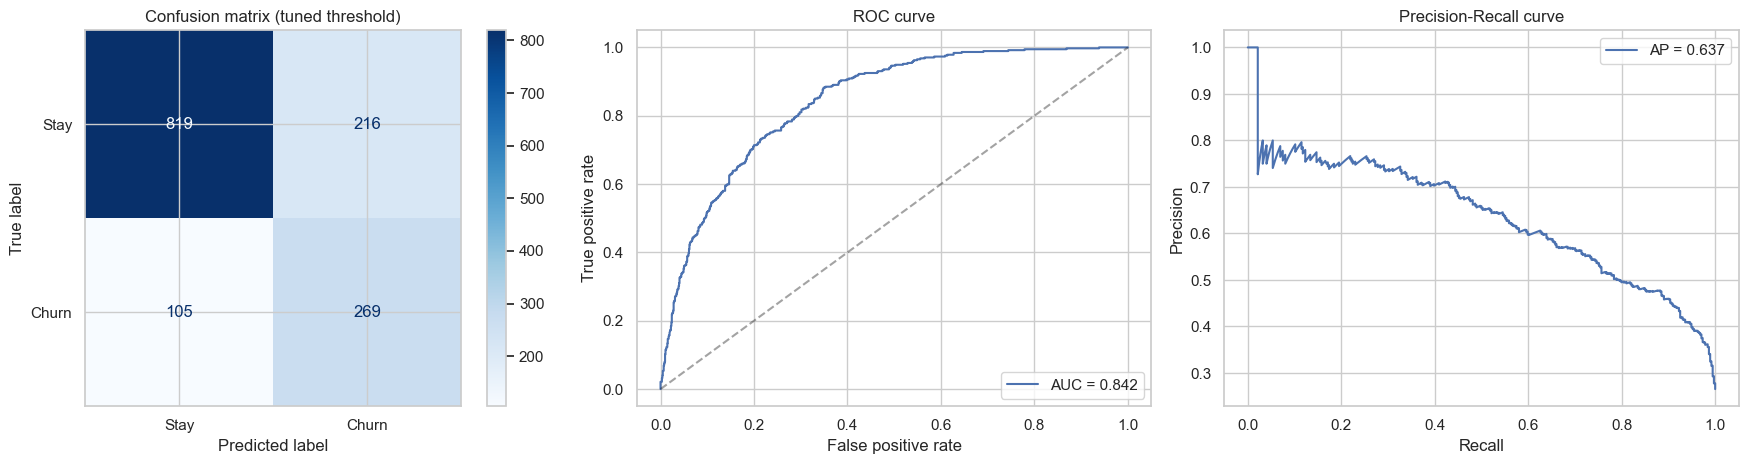

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["Stay", "Churn"], cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix (tuned threshold)")

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve"); axes[1].legend(loc="lower right")

p, r, _ = precision_recall_curve(y_test, proba)
axes[2].plot(r, p, label=f"AP = {average_precision_score(y_test, proba):.3f}")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall curve"); axes[2].legend(loc="upper right")

plt.tight_layout(); plt.show()

## 7. Interpretation — what drives the predictions?

### 7.1 Permutation importance

We shuffle one feature at a time and measure how much **test ROC-AUC drops**.
A big drop means the model relied on that feature. This is model-agnostic and
measured on held-out data, so it reflects genuine predictive value.

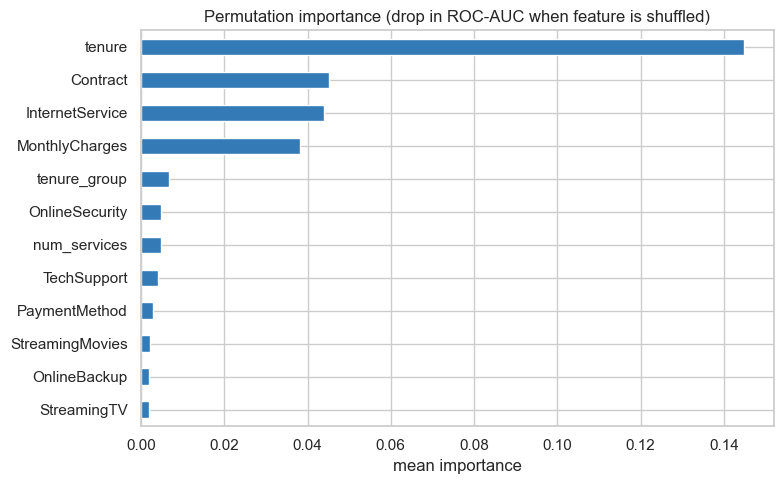

In [18]:
perm = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=10,
    random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
imp.tail(12).plot(kind="barh", color="#337ab7")
plt.title("Permutation importance (drop in ROC-AUC when feature is shuffled)")
plt.xlabel("mean importance"); plt.tight_layout(); plt.show()

### 7.2 Logistic-regression coefficients (direction of effect)

Permutation importance tells us *how much* a feature matters; coefficients tell
us *which direction*. Because inputs were standardised / one-hot encoded, we can
read the sign: **positive → pushes toward churn**, negative → pushes toward
staying. (Only shown when the linear model is selected.)

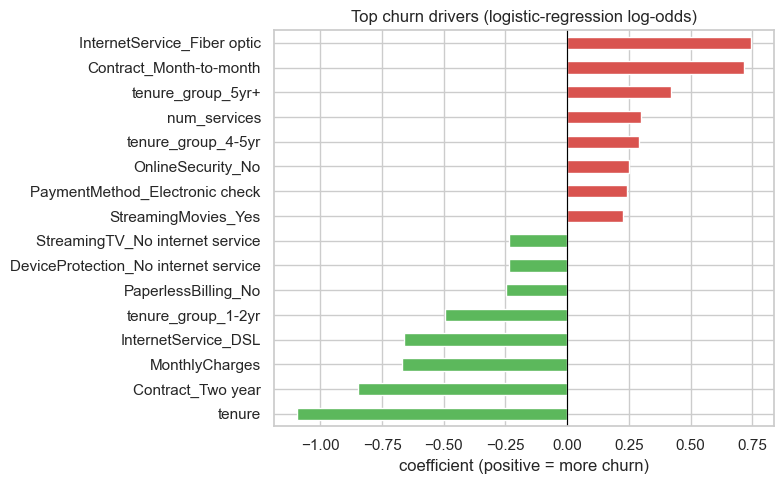

In [19]:
if best_name == "Logistic Regression":
    ohe = best_pipe.named_steps["prep"].named_transformers_["cat"]
    feat_names = numeric_cols + list(ohe.get_feature_names_out(categorical_cols))
    coefs = pd.Series(best_pipe.named_steps["model"].coef_[0], index=feat_names).sort_values()
    top = pd.concat([coefs.head(8), coefs.tail(8)])
    colors = ["#5cb85c" if v < 0 else "#d9534f" for v in top.values]
    top.plot(kind="barh", color=colors)
    plt.title("Top churn drivers (logistic-regression log-odds)")
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("coefficient (positive = more churn)")
    plt.tight_layout(); plt.show()
else:
    print("Best model is not linear; see permutation importance above.")

## 8. Business impact & recommendations

Let's translate the confusion matrix into business language.

In [20]:
tp = int(((pred == 1) & (y_test == 1)).sum())
fp = int(((pred == 1) & (y_test == 0)).sum())
fn = int(((pred == 0) & (y_test == 1)).sum())
total_churners = int(y_test.sum())

print(f"Test set: {len(y_test)} customers, {total_churners} actually churned.")
print(f"  Model correctly flags {tp}/{total_churners} churners "
      f"({tp/total_churners:.0%} recall).")
print(f"  Misses {fn} churners and raises {fp} false alarms.")
print()
print("If a retention offer costs $1 to send and a saved customer is worth $100,")
saved = tp * 100
cost = (tp + fp) * 1
print(f"  contacting the {tp+fp} flagged customers costs ${cost}")
print(f"  and could protect up to ${saved} of revenue (illustrative).")

Test set: 1409 customers, 374 actually churned.
  Model correctly flags 269/374 churners (72% recall).
  Misses 105 churners and raises 216 false alarms.

If a retention offer costs $1 to send and a saved customer is worth $100,
  contacting the 485 flagged customers costs $485
  and could protect up to $26900 of revenue (illustrative).


**Recommendations for the business:**

1. **Lock in month-to-month customers.** They are by far the highest-risk group —
   offer incentives to move to 1- or 2-year contracts.
2. **Protect new customers (tenure < 12 months).** Churn is front-loaded;
   onboarding and early-life engagement matter most.
3. **Investigate fiber-optic & electronic-check segments** — both show elevated
   churn and are worth a pricing / experience review.
4. **Deploy the model to score the active base monthly** and route the top
   risk-ranked customers to retention.

## 9. Conclusion & next steps

We built a complete pipeline — clean → explore → engineer → model → evaluate →
interpret — that predicts churn with **~0.84 ROC-AUC** and recovers ~72% of
churners. A simple, interpretable logistic-regression matched the tree ensembles,
so it's the model we'd ship.

**Next steps:** richer feature engineering (interaction terms, complaints/usage
logs if available), calibrated probabilities for expected-value targeting,
SHAP for per-customer explanations, and a monitoring loop to catch drift.